Configuração inicial

In [519]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None) # Limite de colunas que serão mostradas
pd.set_option("display.max_rows", 100) # Limite de linhas que serão mostradas

plt.rcParams["figure.figsize"] = (10,6) # Tamanho das figuras, largura e altura

Importação da base

In [520]:
df_acre = pd.read_csv("base_dados/MICRODADOS_ENEM_2023_AC.csv")
print("Base carregada com sucesso.")

Base carregada com sucesso.


Checagem dos valores nulos

In [521]:
df_nulos = df_acre.isnull().sum().sort_values(ascending=False) # Contagem de nulos e ordenação decrescente
df_nulos = df_nulos.to_frame("Quantidade de nulos")
df_nulos["Porcentagem"] = (df_acre.isnull().sum() / len(df_acre) * 100).sort_values(ascending=False) # Coluna de porcentagem

print(df_nulos)

                        Quantidade de nulos  Porcentagem
SG_UF_ESC                             20077    82.709895
NO_MUNICIPIO_ESC                      20077    82.709895
TP_SIT_FUNC_ESC                       20077    82.709895
TP_DEPENDENCIA_ADM_ESC                20077    82.709895
TP_LOCALIZACAO_ESC                    20077    82.709895
CO_MUNICIPIO_ESC                      20077    82.709895
CO_UF_ESC                             20077    82.709895
TP_ENSINO                             17746    73.107028
NU_NOTA_CN                             9120    37.571064
NU_NOTA_MT                             9120    37.571064
CO_PROVA_MT                            9120    37.571064
CO_PROVA_CN                            9120    37.571064
NU_NOTA_COMP3                          8112    33.418472
CO_PROVA_CH                            8112    33.418472
NU_NOTA_CH                             8112    33.418472
NU_NOTA_LC                             8112    33.418472
CO_PROVA_LC                    

In [522]:
colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

df_removidos = df_acre.dropna(subset=colunas_notas).copy() # Retira linhas que possuem algum valor de nota nulo

print(df_acre.shape)
print(df_removidos.shape)

(24274, 65)
(15099, 65)


# Análise dos dados envolvendo escola

## Mapeamento das colunas de escolas

In [523]:
df_escolas = df_acre.dropna(subset=['TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC']).copy() # Retira linhas que não possuem esses dados

# Filtra apenas escolas Públicas (2) e Privadas (3)
df_escolas = df_acre[df_acre['TP_ESCOLA'].isin([2, 3])].copy()

mapeamento_localizacao = {1: 'Urbana', 2: 'Rural'}
mapeamento_tp_escola = {2: "Pública", 3: "Privada"}

df_escolas['LOCALIZACAO_ESC'] = df_escolas['TP_LOCALIZACAO_ESC'].map(mapeamento_localizacao)
df_escolas['TP_ESCOLA'] = df_escolas['TP_ESCOLA'].map(mapeamento_tp_escola)

Preenchimento de notas vazias pela mediana

In [524]:

# Preenche dados ausentes pela mediana da coluna
for coluna_nota in colunas_notas:
    df_escolas[coluna_nota] = df_escolas[coluna_nota].fillna(df_escolas[coluna_nota].median())
df_escolas.shape

(6967, 66)

Configuração da coluna de notas

In [525]:
# Cria uma nova coluna e preenche os dados com a média
df_escolas['MEDIA_GERAL'] = df_escolas[colunas_notas].mean(axis=1) 

Comparação entre alunos de escola pública e alunos de escola privada (Média):


In [526]:
comparativo_adm = df_escolas.groupby('TP_ESCOLA')['MEDIA_GERAL'].mean().reset_index()
display(comparativo_adm)

,TP_ESCOLA,MEDIA_GERAL
0,Privada,610.089907
1,Pública,498.371427


Comparação entre alunos de escola em zona rural e zona urbana

In [527]:
comparativo_localizacao = df_escolas.groupby('LOCALIZACAO_ESC')['MEDIA_GERAL'].mean().reset_index()
display(comparativo_localizacao)

,LOCALIZACAO_ESC,MEDIA_GERAL
0,Rural,491.792638
1,Urbana,513.613324


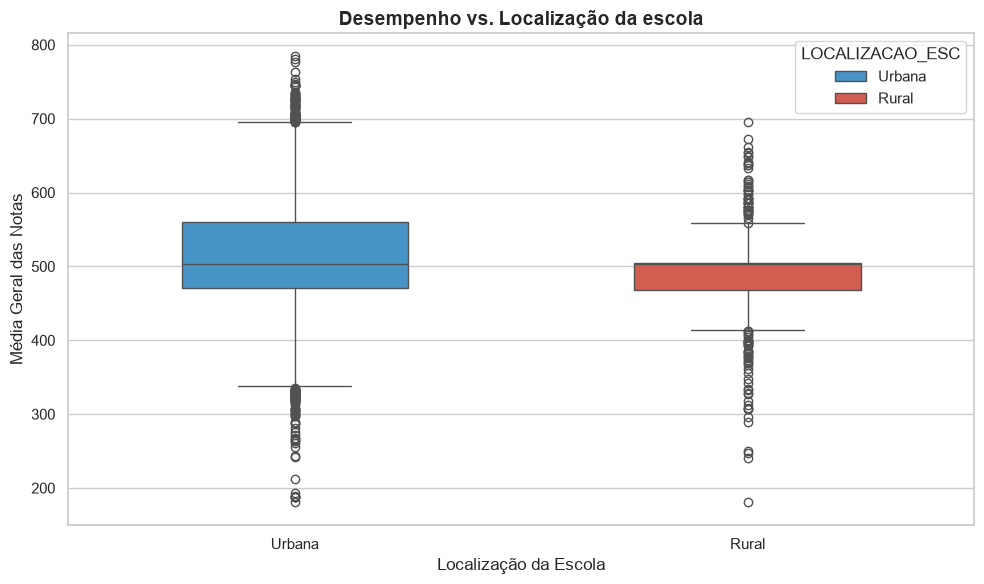

In [528]:
sns.boxplot(
    x='LOCALIZACAO_ESC', 
    y='MEDIA_GERAL', 
    data=df_escolas, 
    palette={'Urbana': '#3498db', 'Rural': '#e74c3c'}, # Cores contrastantes
    width=0.5,
    hue="LOCALIZACAO_ESC"
)

plt.title('Desempenho vs. Localização da escola', fontsize=14, fontweight='bold')
plt.xlabel('Localização da Escola')
plt.ylabel('Média Geral das Notas')
plt.tight_layout()
plt.show()


In [529]:
df_nulos_escola = df_escolas.isnull().sum().sort_values(ascending=False) # Contagem de nulos e ordenação decrescente
print(df_nulos_escola)

TP_SIT_FUNC_ESC           2770
SG_UF_ESC                 2770
CO_MUNICIPIO_ESC          2770
TP_DEPENDENCIA_ADM_ESC    2770
NO_MUNICIPIO_ESC          2770
CO_UF_ESC                 2770
TP_LOCALIZACAO_ESC        2770
LOCALIZACAO_ESC           2770
CO_PROVA_MT               1932
CO_PROVA_CN               1932
CO_PROVA_CH               1640
NU_NOTA_COMP3             1640
NU_NOTA_COMP5             1640
NU_NOTA_COMP2             1640
CO_PROVA_LC               1640
TP_STATUS_REDACAO         1640
NU_NOTA_COMP4             1640
NU_NOTA_COMP1             1640
TP_ENSINO                  439
TP_ESTADO_CIVIL              0
TP_SEXO                      0
TP_FAIXA_ETARIA              0
TP_COR_RACA                  0
CO_UF_PROVA                  0
CO_MUNICIPIO_PROVA           0
TP_PRESENCA_LC               0
SG_UF_PROVA                  0
TP_PRESENCA_MT               0
TP_PRESENCA_CN               0
TP_PRESENCA_CH               0
TP_NACIONALIDADE             0
TP_ANO_CONCLUIU              0
TP_ST_CO

Verificação dos outliers

In [530]:
Q1 = df_escolas["MEDIA_GERAL"].quantile(0.25)
Q3 = df_escolas["MEDIA_GERAL"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

outliers = df_escolas[(df_escolas["MEDIA_GERAL"] < lower) | (df_escolas['MEDIA_GERAL'] > upper)]
print("Outliers em MEDIA_GERAL utilizando IQR:")
print(outliers["MEDIA_GERAL"])


Outliers em MEDIA_GERAL utilizando IQR:
22       724.98
37       674.08
68       666.04
89       321.52
97       340.52
          ...  
23413    314.04
23554    300.86
23561    302.96
23597    325.54
24151    340.42
Name: MEDIA_GERAL, Length: 401, dtype: float64


Gráficos do dataframe de escolas


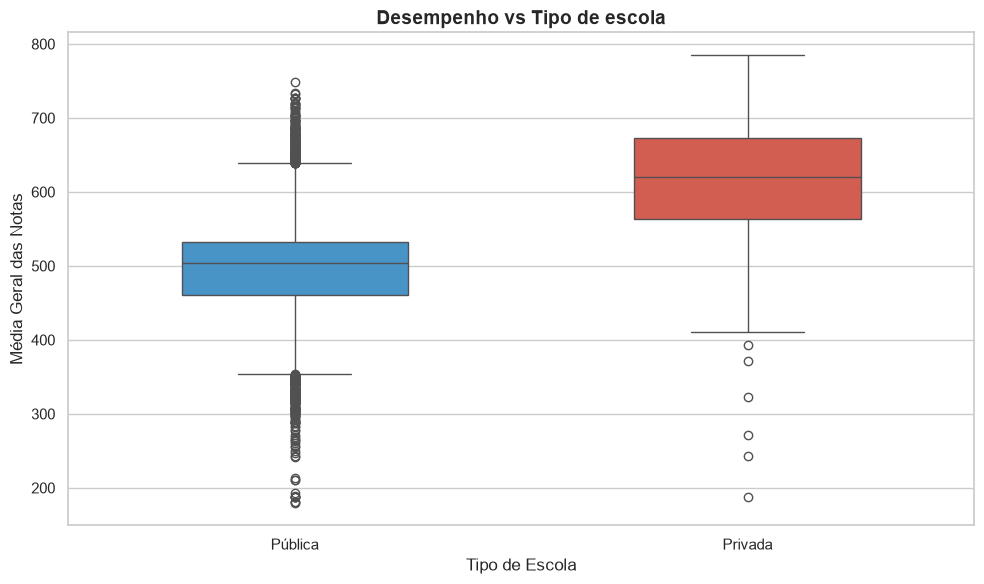

In [531]:
sns.boxplot(
    x='TP_ESCOLA', 
    y='MEDIA_GERAL', 
    data=df_escolas, 
    palette={'Pública': '#3498db', 'Privada': '#e74c3c'}, # Cores contrastantes
    hue='TP_ESCOLA',
    width=0.5
)

plt.title('Desempenho vs Tipo de escola', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Escola')
plt.ylabel('Média Geral das Notas')
plt.tight_layout()
plt.show()


# Mapeamento de colunas do questionário socioeconômico

In [532]:
# Colunas respectivamente: Escolaridade do pai, escolaridade da mãe, renda, celular, computador e internet.
# ["Q001", "Q002", "Q006","Q022","Q024","Q025"]

mapeamento_escolaridade = {
    'A': 1,
    'B': 2,
    'C': 2,
    'D': 3,
    'E' : 4,
    'F' : 5,
    'G' : 5,
}

# O que será mostrado no gráfico
labels_escolaridade = {
    1: 'Nunca estudou',
    2: 'Fundamental incompleto',
    3: 'Fundamental completo',
    4: 'Ensino médio completo',
    5: 'Superior completo',
}

# Guarda as escolaridades em ordem crescente
ordem_labels = [labels_escolaridade[i] for i in labels_escolaridade]

df_questionario = df_acre.copy()

Análise da correlação entre escolaridade do responsável e nota média do candidato

In [533]:
colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
df_questionario['MEDIA_GERAL'] = df_questionario[colunas_notas].mean(axis=1)

# Mostra a média geral para cada resposta de Q002
analise_mae = df_questionario.groupby('Q002')['MEDIA_GERAL'].mean().reset_index()
display(analise_mae)

,Q002,MEDIA_GERAL
0,A,459.188216
1,B,474.732266
2,C,486.913008
3,D,492.810207
4,E,510.339688
5,F,542.508309
6,G,556.809427
7,H,480.724850


In [534]:
analise_pai = df_questionario.groupby('Q001')['MEDIA_GERAL'].mean().reset_index()
display(analise_pai)

,Q001,MEDIA_GERAL
0,A,468.566669
1,B,481.422680
2,C,495.692613
3,D,502.960069
4,E,519.489046
5,F,557.637237
6,G,563.564012
7,H,497.576880


Boxplots de Nota Média do Candidato vs. Escolaridade do responsável

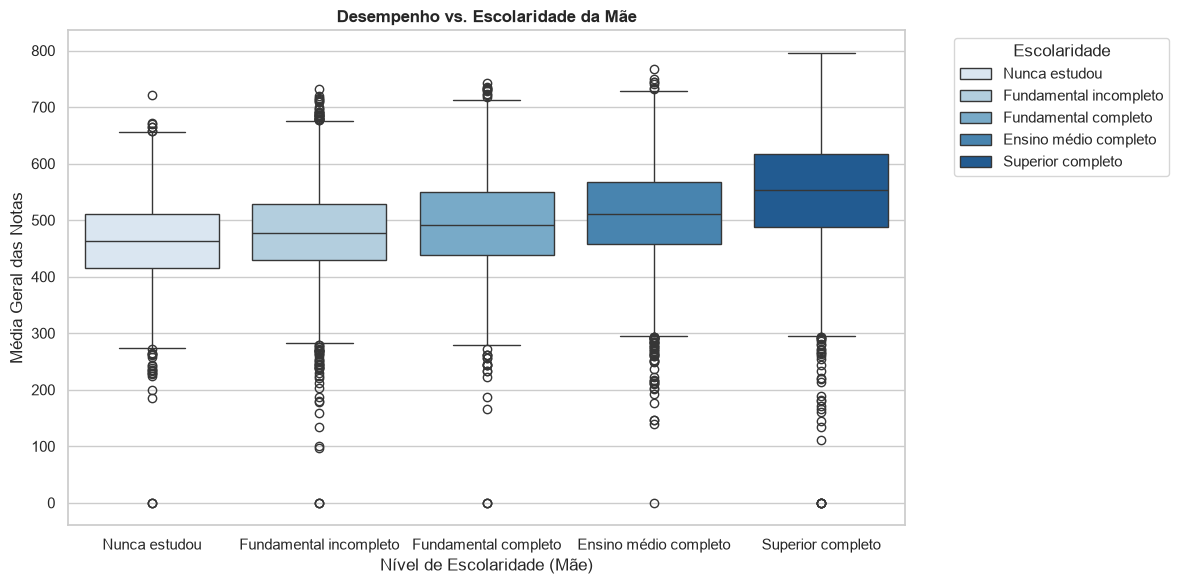

In [535]:
df_questionario['ROTULO_PAI'] = df_questionario['Q001'].map(mapeamento_escolaridade).map(labels_escolaridade)
df_questionario['ROTULO_MAE'] = df_questionario['Q002'].map(mapeamento_escolaridade).map(labels_escolaridade)

plt.figure(figsize=(12, 6)) 

sns.boxplot(
    x='ROTULO_MAE',
    y='MEDIA_GERAL',
    data=df_questionario,
    order=ordem_labels,
    palette='Blues',
    hue='ROTULO_MAE',
    hue_order=ordem_labels
)

plt.title('Desempenho vs. Escolaridade da Mãe', fontsize=12, fontweight='bold')
plt.xlabel('Nível de Escolaridade (Mãe)')
plt.ylabel('Média Geral das Notas')
plt.legend(title='Escolaridade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

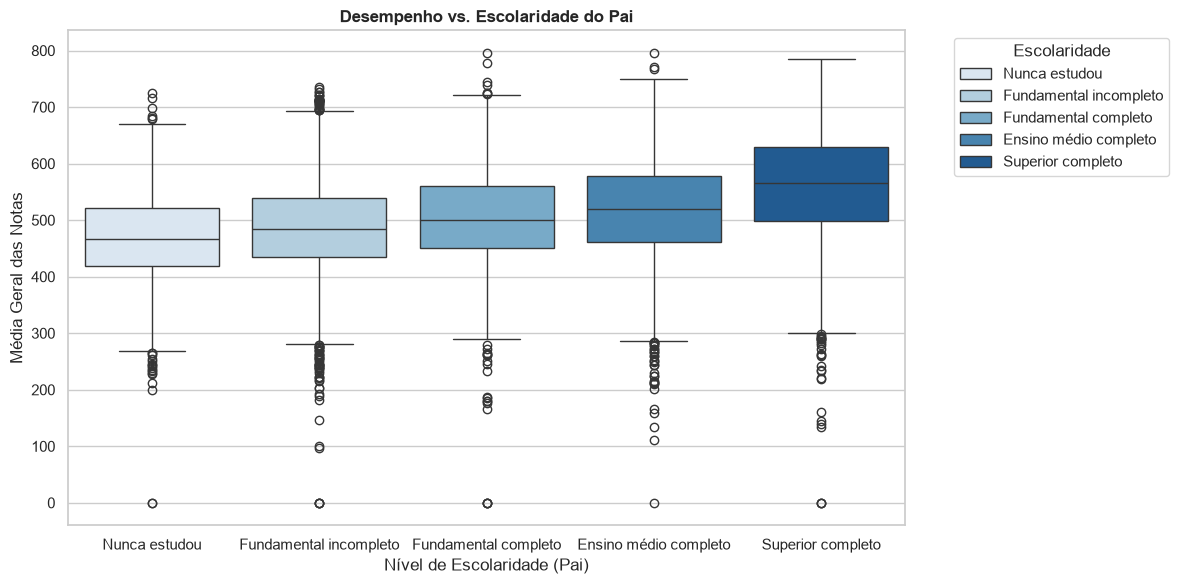

In [536]:
plt.figure(figsize=(12, 6)) 

# 2. Atualizando o eixo X para a coluna mapeada
sns.boxplot(
    x='ROTULO_PAI',       # Usando a coluna mapeada em vez de 'Q002'
    y='MEDIA_GERAL',
    data=df_questionario,
    order=ordem_labels,   # Agora o eixo X e a ordem possuem os mesmos textos
    palette='Blues',
    hue='ROTULO_PAI',
    hue_order=ordem_labels
)

plt.title('Desempenho vs. Escolaridade do Pai', fontsize=12, fontweight='bold')
plt.xlabel('Nível de Escolaridade (Pai)')
plt.ylabel('Média Geral das Notas')
plt.legend(title='Escolaridade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

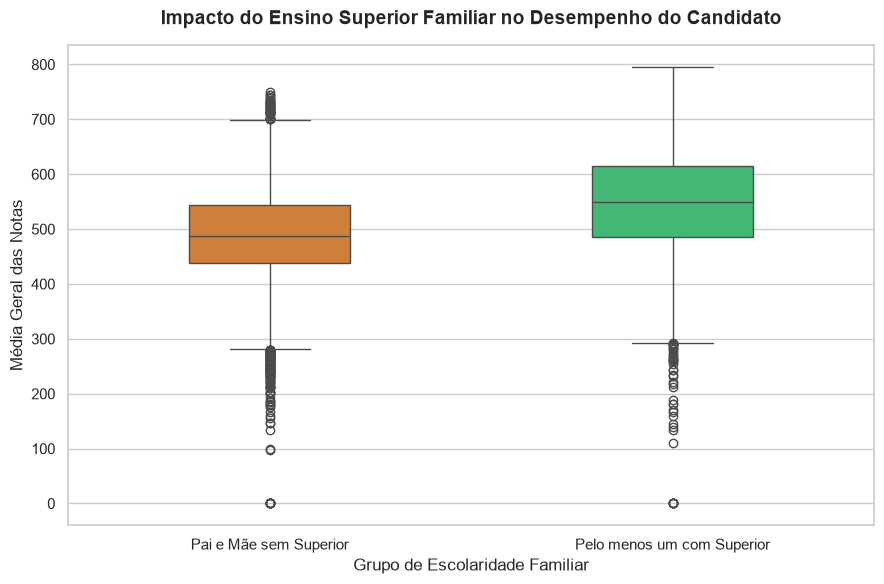

In [537]:
# Pega somente F e G que equivalem a graduação e pós graduação
pelo_menos_um_superior = df_questionario['Q001'].isin(['F', 'G']) | df_questionario['Q002'].isin(['F', 'G'])
ambos_sem_superior = ~pelo_menos_um_superior # Não tem pelo menos um com superior

df_grupos_escolaridade = df_questionario[pelo_menos_um_superior | ambos_sem_superior].copy() # COloca os dados em um novo df

# Cria uma coluna nova e onde a afirmação for verdadeira substitui pelo rotulo
df_grupos_escolaridade.loc[pelo_menos_um_superior, 'GRUPO_SUPERIOR'] = 'Pelo menos um com Superior' 
df_grupos_escolaridade.loc[ambos_sem_superior, 'GRUPO_SUPERIOR'] = 'Pai e Mãe sem Superior' 

plt.figure(figsize=(9, 6))
sns.boxplot(
    x='GRUPO_SUPERIOR',
    y='MEDIA_GERAL',
    data=df_grupos_escolaridade,
    # Agora a chave do dicionário bate exatamente com o DataFrame
    palette={'Pelo menos um com Superior': '#2ecc71', 'Pai e Mãe sem Superior': '#e67e22'},
    hue='GRUPO_SUPERIOR',
    legend=False,
    width=0.4
)

plt.title('Impacto do Ensino Superior Familiar no Desempenho do Candidato', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Grupo de Escolaridade Familiar', fontsize=12)
plt.ylabel('Média Geral das Notas', fontsize=12)
plt.tight_layout()
plt.show()

Mapeamento de renda familiar do candidato

Boxplot de Renda familiar x Desempenho

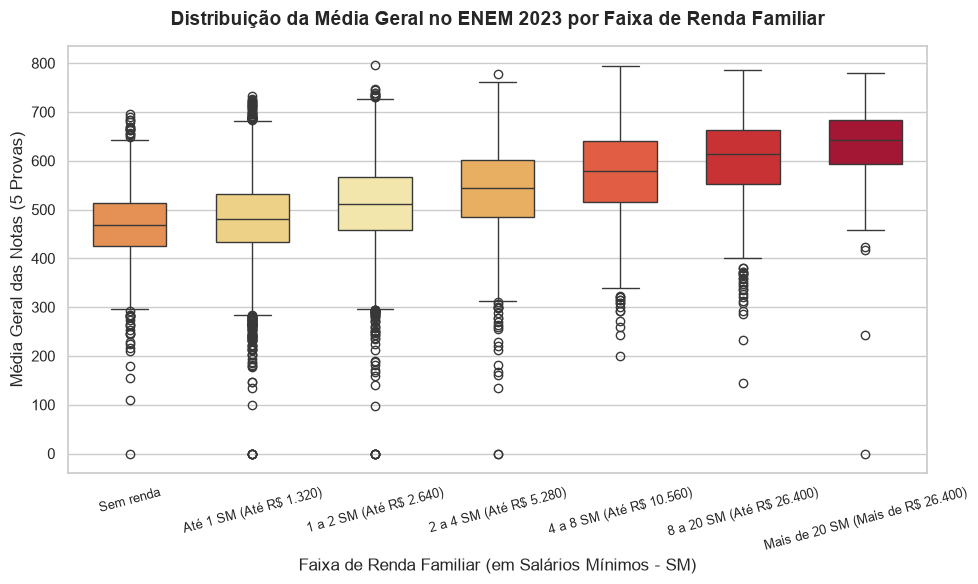

In [ ]:
mapeamento_renda = {
    'A': 1,
    'B': 2,
    'C': 3, 'D': 3,
    'E': 4, 'F': 4, 'G': 4,
    'H': 5, 'I': 5, 'J': 5, 'K': 5,
    'L': 6, 'M': 6, 'N': 6, 'O': 6, 'P': 6,
    'Q': 7
}

df_renda = df_acre.copy()
df_renda['RENDA_FAMILIAR_NUM'] = df_renda['Q006'].map(mapeamento_renda)

df_renda['Q006'] = df_renda['Q006'].map(mapeamento_renda)
colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
df_renda['MEDIA_GERAL'] = df_renda[colunas_notas].mean(axis=1)


labels_renda = {
    1: 'Sem renda',
    2: 'Até 1 SM (Até R$ 1.320)',
    3: '1 a 2 SM (Até R$ 2.640)',
    4: '2 a 4 SM (Até R$ 5.280)',
    5: '4 a 8 SM (Até R$ 10.560)',
    6: '8 a 20 SM (Até R$ 26.400)',
    7: 'Mais de 20 SM (Mais de R$ 26.400)'
}

ordem_renda = [labels_renda[i] for i in sorted(labels_renda.keys())]

df_renda['ROTULO_RENDA'] = df_renda['RENDA_FAMILIAR_NUM'].map(labels_renda)
ordem_renda = [labels_renda[i] for i in sorted(labels_renda.keys())]

sns.boxplot(
    x='ROTULO_RENDA',
    y='MEDIA_GERAL',
    data=df_renda,
    order=ordem_renda,
    palette='YlOrRd',
    hue='ROTULO_RENDA',
    legend=False,
    width=0.6
)

plt.title('Distribuição da Média Geral no ENEM 2023 por Faixa de Renda Familiar', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Faixa de Renda Familiar (em Salários Mínimos - SM)', fontsize=12)
plt.ylabel('Média Geral das Notas', fontsize=12)
plt.xticks(rotation=15, fontsize=9) # Rotacionando as faixas de texto para legibilidade

plt.tight_layout()
plt.show()

Análise de distribuição e Assimetria

In [ ]:
skew_antes = df_acre[colunas_notas].skew()
df_acre = df_acre.loc[df_acre['NU_NOTA_REDACAO'] > 0]
skew_depois = df_acre[colunas_notas].skew()

print(skew_antes)


NU_NOTA_CN        -0.927896
NU_NOTA_CH        -0.760987
NU_NOTA_LC        -0.716834
NU_NOTA_MT         0.046204
NU_NOTA_REDACAO   -0.544573
dtype: float64
NU_NOTA_CN        -0.785729
NU_NOTA_CH        -0.534290
NU_NOTA_LC        -0.448804
NU_NOTA_MT         0.124278
NU_NOTA_REDACAO    0.173039
dtype: float64


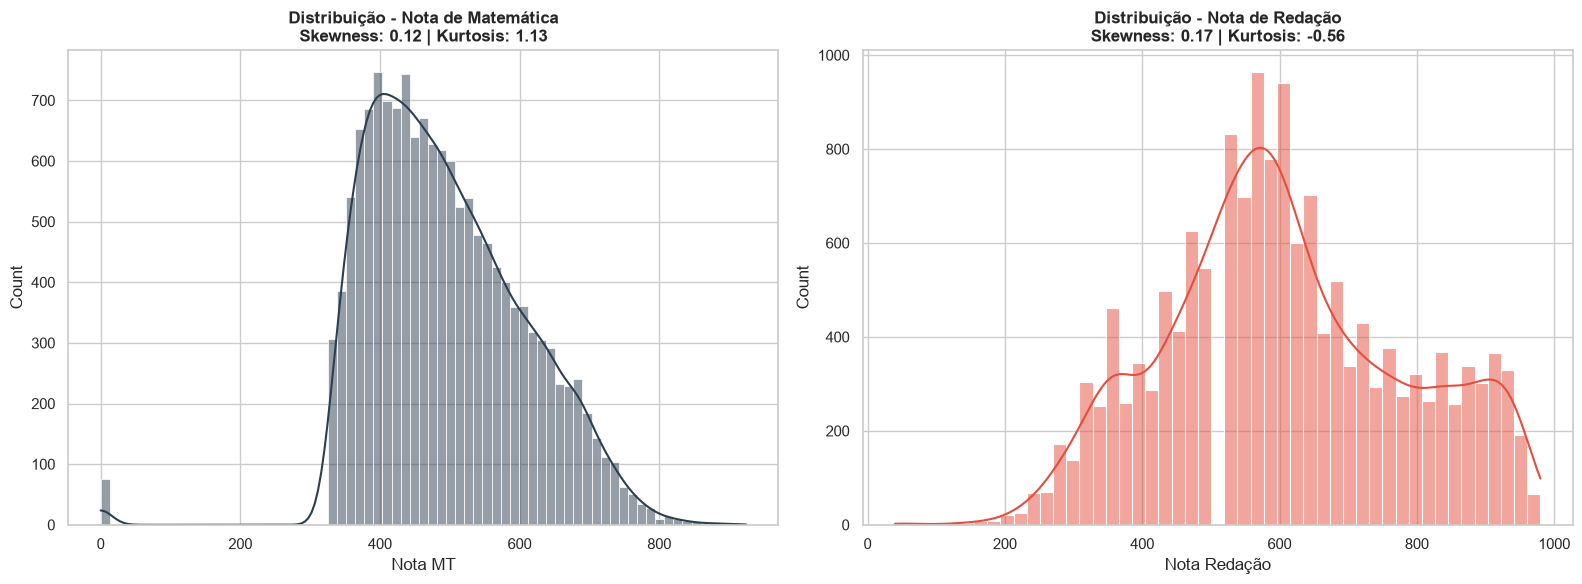

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Estrutura para dois gráficos em uma só figura

df_assimetria = df_acre.copy()

# Nota matemática
nota_mt = df_assimetria['NU_NOTA_MT'].dropna() # Removendo nulos para não quebrar o cálculo
skew_mt = nota_mt.skew() # Assimetria, verifica o quão "puxado" para os lados a curva está
kurt_mt = nota_mt.kurt() # Curtose, verifica o quão "pontudo" ou achatado o gráfico está

sns.histplot(ax=axes[0], x=nota_mt, kde=True, color='#2c3e50')
axes[0].set_title(f'Distribuição - Nota de Matemática\nSkewness: {skew_mt:.2f} | Kurtosis: {kurt_mt:.2f}', 
                  fontsize=12, 
                  fontweight='bold')
axes[0].set_xlabel('Nota MT')

# Nota redação

nota_red = df_assimetria.loc[df_assimetria['NU_NOTA_REDACAO'] > 0, 'NU_NOTA_REDACAO'] # Remove valores nulos e zeros
skew_red = nota_red.skew()
kurt_red = nota_red.kurt()

sns.histplot(ax=axes[1], x=nota_red, kde=True, color='#e74c3c')
axes[1].set_title(f'Distribuição - Nota de Redação\nSkewness: {skew_red:.2f} | Kurtosis: {kurt_red:.2f}', 
                  fontsize=12, 
                  fontweight='bold')
axes[1].set_xlabel('Nota Redação')

plt.tight_layout()
plt.show()